In [42]:
%matplotlib widget

import time
import matplotlib.pyplot as plt
from moku.instruments import FrequencyResponseAnalyzer
import traceback

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

## Estilo dos gráficos ######################################################################################################

plt.style.use('default') # Gráficos com fundo branco
# plt.rcParams["figure.autolayout"] = True
# plt.rcParams["figure.figsize"] = [16, 9] # [7, 4] # [8, 5]
plt.style.use({
    'figure.figsize': [7,4], 'figure.constrained_layout.use': True, #'text.usetex' : True,
    'axes.titlesize': 14, 'legend.fontsize': 10, 'axes.labelsize': 10,'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

In [43]:
## CONEXÃO E COLETA DE DADOS ################################################################################################

MOKU_IP = '192.168.73.1' # IP do equipamento
FRA = None # Garante que a variável existe, mesmo se a conexão explodir. FRA: Frequency Response Analyzer

try:
    print(f"Buscando o Moku:Go na rede pelo IP: {MOKU_IP} ...")
    FRA = FrequencyResponseAnalyzer(MOKU_IP, force_connect=True) # 'force_connect=True' garante controle mesmo com o app aberto
    print("Conexão bem-sucedida! Configurando o instrumento ...")
    
    # 1. Configura a varredura
    FRA.set_defaults()
    FRA.set_frontend(1, impedance='1MOhm', coupling='DC', range='10Vpp')
    FRA.set_frontend(2, impedance='1MOhm', coupling='DC', range='10Vpp')
    FRA.set_sweep(
        start_frequency=100, stop_frequency=100e3, num_points=256,
        settling_cycles=2, averaging_cycles=2, strict=False
    )
    FRA.set_output(1, amplitude=1.0, offset=0.0)
    
    # 3. Inicia a varredura, espera terminar e extrai os dados
    print("Iniciando varredura ... (Script em espera)")
    FRA.start_sweep()
    data = FRA.get_data(wait_complete=True)
    
    # 4. Extração e Tratamento dos Dados (Convertendo saída do Moku para Arrays do NumPy)
    print("Extraindo matrizes de dados da RAM...")
    freqs = np.array(data['ch1']['frequency'])

    # Chaves da API do MokuGo ('magnitude' e 'phase')
    mag_ch1 = np.array(data['ch1']['magnitude'])
    mag_ch2 = np.array(data['ch2']['magnitude'])
    phase_ch1 = np.array(data['ch1']['phase'])
    phase_ch2 = np.array(data['ch2']['phase'])
    
    # A atenuação real do filtro (CH2 - CH1) --> Magnitude (dB) = 20 * log10(|Vout/Vin|) = Mag_CH2(dB) - Mag_CH1(dB)
    transfer_magnitude = mag_ch2 - mag_ch1
    transfer_phase = np.rad2deg( np.unwrap( np.deg2rad(phase_ch2 - phase_ch1) ) ) # Unwrap da fase para evitar saltos de 360 graus

    # Força o teto experimental a ser 0 dB para remover os 20dB de ganho fantasma do MokuGo
    offset_residual = transfer_magnitude.max()
    transfer_magnitude = transfer_magnitude - offset_residual

except Exception as e:
    traceback.print_exc()

finally: # Libera o instrumento para não travar o Moku:Go
    if FRA is not None: # Só libera se o instrumento estava conectado
        FRA.relinquish_ownership()
        print("Conexão encerrada")

Buscando o Moku:Go na rede pelo IP: 192.168.73.1 ...
Conexão bem-sucedida! Configurando o instrumento ...
Iniciando varredura ... (Script em espera)
Extraindo matrizes de dados da RAM...
Conexão encerrada



 ======= RESULTADOS DA OTIMIZAÇÃO =======
Teórica      : fc   = 3692.69 Hz ± 261.11 Hz
Experimental : fc   = 3575.53 Hz ± 2.22 Hz
Divergência  : 117.16Hz -> 3.17 %
Passagem     : T    = 0.03 dB 



C:\Users\Varlei\AppData\Local\Temp\ipykernel_22196\3951726551.py:93: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect1, (c1, c2, c3, c4) = ax1.indicate_inset_zoom(axins1, edgecolor="gray")


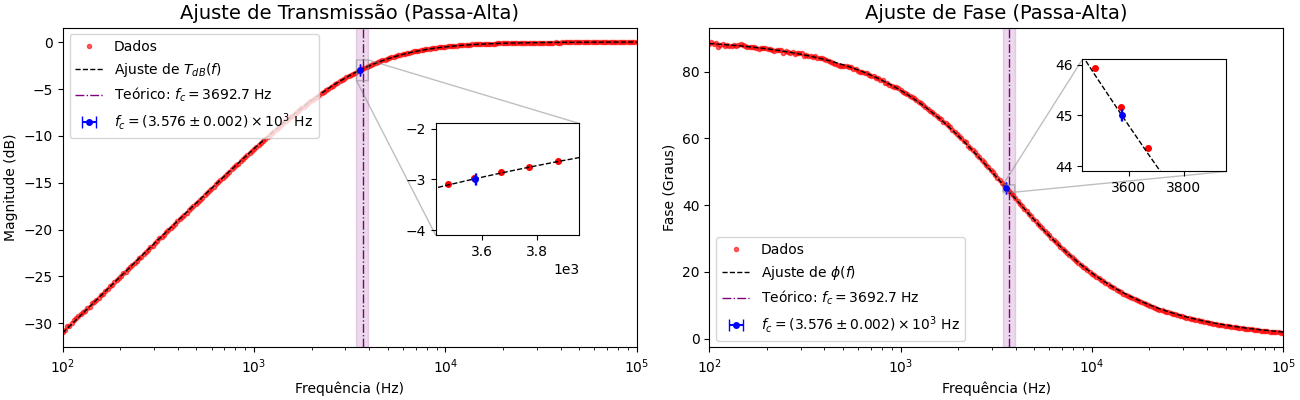

In [44]:
## OTIMIZAÇÃO DE CURVA (Curve Fit) ##########################################################################################

# Valores e Tolerâncias nominais dos componentes (datasheet)
R_teo, C_teo = 4.31e3, 10e-9
tol_R, tol_C = 0.05, 0.05 # 5% para o Resistor, 10% para o Capacitor
sig_R = R_teo * tol_R
sig_C = C_teo * tol_C

# Cálculo teórico e propagação de incerteza
fc_teo = 1 / (2 * np.pi * R_teo * C_teo)
sig_fc_teo = fc_teo * np.sqrt((sig_R / R_teo)**2 + (sig_C / C_teo)**2)

# 1. Colocando os dados no Pandas
df = pd.DataFrame({
    'Frequency'   : freqs,
    'Magnitude_dB': transfer_magnitude,
    'Phase_deg'   : transfer_phase
})

# 2. Definindo o modelo matemático com correção experimental
def Transmissao_dB(f, fc, T_pass):
    return 20 * np.log10(f / fc) - 10 * np.log10( 1 + (f / fc)**2 ) + T_pass

def Fase_graus(f, fc):
    return np.rad2deg( np.arctan(fc / f) )

# 3. Palpites Iniciais (p0) Dinâmicos
T_pass = df['Magnitude_dB'].max() # Transmissão na banda de passagem (máximo; idealmente T ~ 0dB)
Tc = T_pass - 3 # Transmissão de corte (queda de 3dB; idealmente T ~ -3dB)
idx_fc = (df['Magnitude_dB'] - Tc).abs().argmin() # Índice da queda de 3dB
fc = df['Frequency'].iloc[idx_fc] # Frequência de corte (queda de 3dB)

# 4. Ajuste Fino (Curve Fit)
popt, pcov = curve_fit(
    f=Transmissao_dB,
    xdata=df['Frequency'],
    ydata=df['Magnitude_dB'],
    p0=[fc, T_pass],
    bounds=([0, -np.inf], [np.inf, np.inf]) # fc > 0, T_dB livre
)

fc_opt, T_pass_opt = popt # Parâmetros Otimizados
sig_fc_exp = np.sqrt(pcov[0, 0]) # Diagonal da matriz de covariância é a variância dos parâmetros.

print("\n"," RESULTADOS DA OTIMIZAÇÃO ".center(40, "="))
print(f"Teórica      : fc   = {fc_teo:.2f} Hz ± {sig_fc_teo:.2f} Hz")
print(f"Experimental : fc   = {fc_opt:.2f} Hz ± {sig_fc_exp:.2f} Hz")
print(f"Divergência  : {abs(fc_opt - fc_teo):.2f}Hz -> {abs(fc_opt - fc_teo)/fc_teo*100:.2f} %")
print(f"Passagem     : T    = {T_pass_opt:.2f} dB \n")

# 5. Plotagem Estilo Artigo Científico
df['Fitted_Magnitude'] = Transmissao_dB(df['Frequency'], fc_opt, T_pass_opt)
df['Fitted_Phase'] = Fase_graus(df['Frequency'], fc_opt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

# =====================================================================
# GRÁFICO 1: TRANSMISSÃO
# =====================================================================
ax1.semilogx(df['Frequency'], df['Magnitude_dB'], 'ro', label='Dados', markersize=3, alpha=0.6)
ax1.semilogx(df['Frequency'], df['Fitted_Magnitude'], 'k--', label='Ajuste de $T_{dB}(f)$', linewidth=1)

# Banda de incerteza teórica (Tolerância Nominal)
ax1.axvline(fc_teo, color='purple', linestyle='-.', label=f'Teórico: $f_c=${fc_teo:.1f} Hz', linewidth=1)
ax1.axvspan(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo, color='purple', alpha=0.15)

# Ponto de fc_exp com Barra de Erro
fc_scale = fc_opt / 1000
sig_scale = sig_fc_exp / 1000
label_fc = f'$f_c = ({fc_scale:.3f} \\pm {sig_scale:.3f}) \\times 10^3$ Hz'
ax1.errorbar(fc_opt, Tc, xerr=sig_fc_exp, fmt='bo', label=label_fc,  capsize=4, markersize=4)

# Formatação dos Eixos Principais
ax1.set_title('Ajuste de Transmissão (Passa-Alta)')
ax1.set_xlabel('Frequência (Hz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.tick_params(axis='both', which='major')
ax1.legend(loc='upper left')
ax1.set_xlim(min(df['Frequency']), max(df['Frequency']))

# Inset (Janela de Zoom)
axins1 = ax1.inset_axes([0.65, 0.35, 0.25, 0.35]) # [posição_x, posição_y, largura, altura]; tudo em proporção de 0 a 1
axins1.plot(df['Frequency'], df['Magnitude_dB'], 'ro', markersize=4)       # Escala linear ('plot' no lugar de 'semilogx')
axins1.plot(df['Frequency'], df['Fitted_Magnitude'], 'k--', linewidth=1) # Escala linear ('plot' no lugar de 'semilogx')
axins1.errorbar(fc_opt, Tc, xerr=sig_fc_exp, fmt='bo', capsize=4, markersize=4)
axins1.set_xlim(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo) # Limites do zoom
axins1.set_ylim(Tc - 1.1, Tc + 1.1)                       # Limites do zoom

# Forçando a notação científica no eixo X do inset para replicar a imagem
axins1.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# Desenhando as linhas cinzas de conexão entre o gráfico principal e o zoom
rect1, (c1, c2, c3, c4) = ax1.indicate_inset_zoom(axins1, edgecolor="gray")
c1.set_visible(True)   # Inferior Esquerdo
c2.set_visible(False)  # Superior Esquerdo
c3.set_visible(False)  # Inferior Direito
c4.set_visible(True)   # Superior Direito

# =====================================================================
# GRÁFICO 2: FASE
# =====================================================================
ax2.semilogx(df['Frequency'], df['Phase_deg'], 'ro', label='Dados', markersize=3, alpha=0.6)
ax2.semilogx(df['Frequency'], df['Fitted_Phase'], 'k--', label='Ajuste de $\\phi(f)$', linewidth=1)

ax2.axvline(fc_teo, color='purple', linestyle='-.', label=f'Teórico: $f_c=${fc_teo:.1f} Hz', linewidth=1)
ax2.axvspan(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo, color='purple', alpha=0.15)

# Ponto de fc_exp com Barra de Erro
Fc = Fase_graus(fc_opt, fc_opt)
ax2.errorbar(fc_opt, Fc, xerr=sig_fc_exp, fmt='bo', label=label_fc, capsize=4, markersize=4)

ax2.set_title('Ajuste de Fase (Passa-Alta)')
ax2.set_xlabel('Frequência (Hz)')
ax2.set_ylabel('Fase (Graus)')
ax2.legend(loc='lower left')

# Inset (Zoom) - Canto superior direito (longe da curva que já desceu para perto de 0)
axins2 = ax2.inset_axes([0.65, 0.55, 0.25, 0.35]) 
axins2.plot(df['Frequency'], df['Phase_deg'], 'ro', markersize=4)
axins2.plot(df['Frequency'], df['Fitted_Phase'], 'k--', linewidth=1)
axins2.errorbar(fc_opt, Fc, xerr=sig_fc_exp, fmt='bo', capsize=4, markersize=4)
axins2.set_xlim(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo)
axins2.set_ylim(Fc - 1.1, Fc + 1.1)
axins1.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax2.indicate_inset_zoom(axins2, edgecolor="gray")
